### Setup and Reload Cleaned Data
This notebook performs exploratory data analysis on the cleaned outputs from 02_data_cleaning.ipynb. All datasets are reloaded from 05_processed/ so this notebook can run independently.

In [26]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

# Reload cleaned datasets produced by 02_data_cleaning.ipynb
census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))
zapmap_clean  = pd.read_csv(os.path.join(BASE, "05_processed/zapmap_clean.csv"), parse_dates=["charging_start"])

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, "
      f"osev_london: {osev_london.shape}, zapmap_clean: {zapmap_clean.shape}")

Datasets reloaded.
census_london: (4994, 4), imd_london: (4994, 10), osev_london: (23015, 11), zapmap_clean: (215037, 20)


## Block A — Income Deprivation Distribution

This block joins the income domain score (IoD2025 File 7) to LSOA 2021 boundary geometries and produces a choropleth map of income deprivation across Greater London. This map establishes the spatial baseline for the equity argument developed in later notebooks: LSOAs with higher income deprivation scores are the ones that receive the largest demand uplift under the (1 + α·IMDᵢ) equity weighting in Phase 1.

### peek boundary file

In [27]:
# Load LSOA 2021 boundary geometries (ONS Open Geography, Generalised Clipped V5)
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))

print("Shape:", lsoa_boundaries.shape)
print("Columns:", lsoa_boundaries.columns.tolist())
print("CRS:", lsoa_boundaries.crs)
lsoa_boundaries.head(3)

Shape: (35672, 9)
Columns: ['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry']
CRS: EPSG:27700


,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,NaN,532123,181632,51.5182,-0.09715,86214465-5cf4-4e8f-9492-3667471c42d6,"POLYGON ((532105.312 182010.574, 532162.491 18..."
1,E01000002,City of London 001B,NaN,532480,181715,51.5188,-0.09197,cd40c491-6567-405f-8c18-426e17b356ce,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,E01000003,City of London 001C,NaN,532239,182033,51.5217,-0.09533,7fd27aaf-d858-4e46-9099-92b43f66b948,"POLYGON ((532135.138 182198.131, 532158.25 182..."


### reproject, filter to London, merge income score

In [28]:
# Reproject to EPSG:27700 (British National Grid) — standard for all spatial operations
# in this dissertation, consistent with candidate site generation in later notebooks
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

# Restrict to the 4,994 Greater London LSOAs already confirmed in census_london
# NOTE: assumes the boundary file's LSOA code column is named 'LSOA21CD' (ONS standard).
# Check the printed column list above and adjust this name if it differs.
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

# Merge income score onto boundary geometries
income_map = lsoa_london[["lsoa_code", "geometry"]].merge(
    imd_london[["lsoa_code", "income_score", "income_decile"]],
    on="lsoa_code", how="left"
)
print("Missing income_score after merge:", income_map["income_score"].isna().sum())

LSOA boundaries matched: 4994 / 4994 expected
Missing income_score after merge: 0


### Fig A1 — income score choropleth

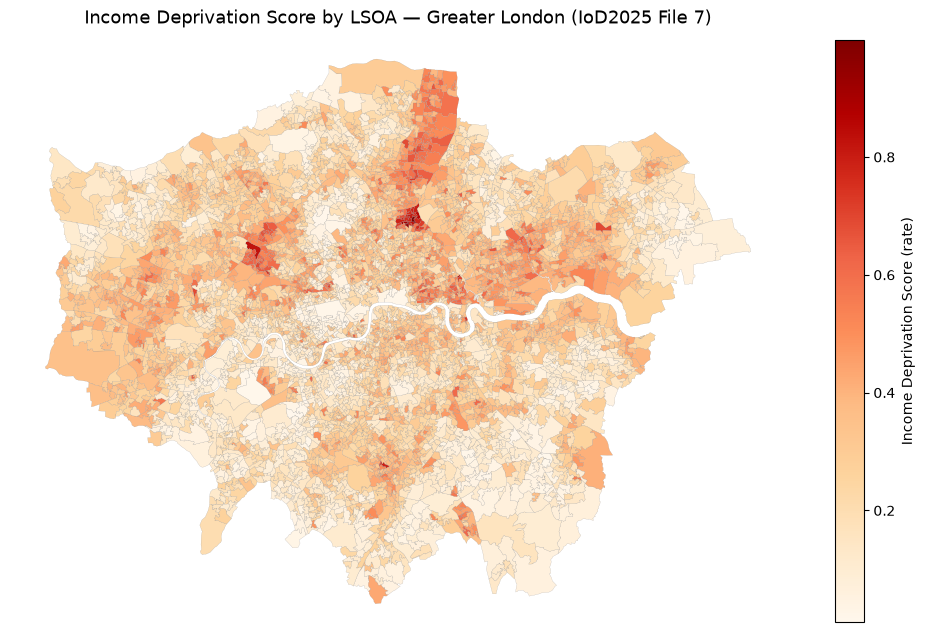

Saved: fig_income_score_map.png


In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
income_map.plot(
    column="income_score", cmap="OrRd", linewidth=0.1,
    edgecolor="grey", legend=True, ax=ax,
    legend_kwds={"label": "Income Deprivation Score (rate)", "shrink": 0.6}
)
ax.set_title("Income Deprivation Score by LSOA — Greater London (IoD2025 File 7)", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_income_score_map.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_income_score_map.png")

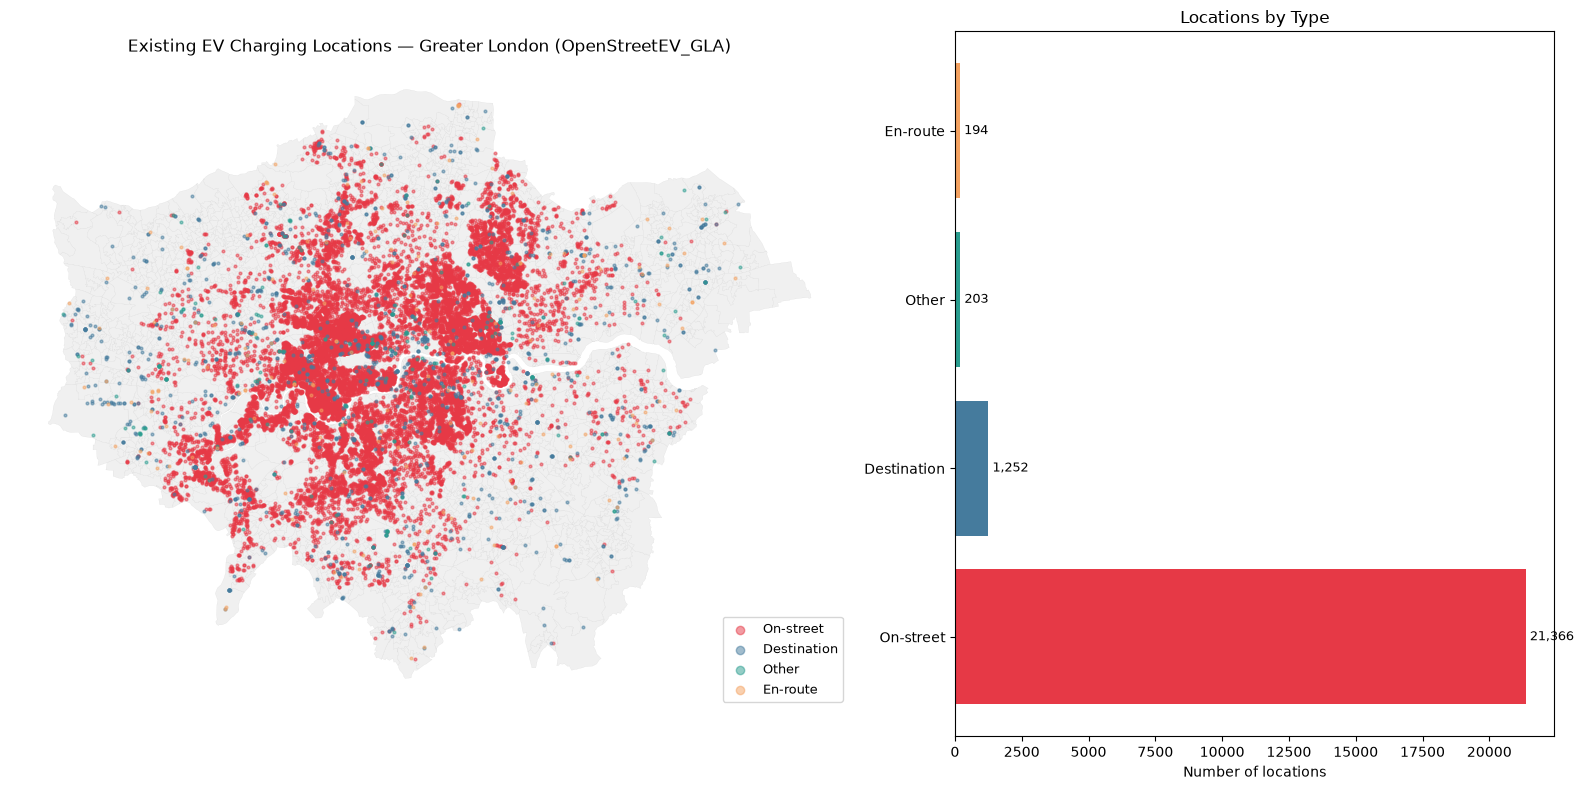

Saved: fig_evse_point_distribution.png

location_type
On-street      21366
Destination     1252
Other            203
En-route         194


In [50]:
# EVSE point distribution map — all location types (not just On-street/Destination), with breakdown bar chart
osev_valid = osev_london.dropna(subset=["latitude", "longitude"]).copy()
osev_pts = gpd.GeoDataFrame(
    osev_valid,
    geometry=gpd.points_from_xy(osev_valid["longitude"], osev_valid["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1.4, 1]})

lsoa_london.plot(ax=ax_map, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.1)

# Plot every location_type present in the data, not just the two most common ones
type_colours = {"On-street": "#e63946", "Destination": "#457b9d", "Other": "#2a9d8f", "En-route": "#f4a261"}
present_types = osev_pts["location_type"].unique()
for loc_type in present_types:
    colour = type_colours.get(loc_type, "#999999")  # fallback grey for any unanticipated category
    subset = osev_pts[osev_pts["location_type"] == loc_type]
    subset.plot(ax=ax_map, color=colour, markersize=4, alpha=0.5, label=loc_type)

ax_map.set_title("Existing EV Charging Locations — Greater London (OpenStreetEV_GLA)")
ax_map.axis("off")
ax_map.legend(loc="lower right", fontsize=9, markerscale=3)

type_counts = osev_pts["location_type"].value_counts()
bar_colours = [type_colours.get(t, "#999999") for t in type_counts.index]
ax_bar.barh(type_counts.index, type_counts.values, color=bar_colours)
ax_bar.set_xlabel("Number of locations")
ax_bar.set_title("Locations by Type")
for i, (label, val) in enumerate(type_counts.items()):
    ax_bar.text(val, i, f" {val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_evse_point_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_evse_point_distribution.png")
print()
print(type_counts.to_string())

## Block B — Utilisation-Adjusted Supply Baseline (Sᵢᵉᶠᶠ)

This block computes the time-based utilisation rate urⱼ for every EVSE active in the GLA/Zapmap session data (following the definition formalised by Borlaug et al. 2023), spatially joins EVSE locations to LSOAs, and aggregates residual effective capacity Sᵢᵉᶠᶠ = Σ(1 − urⱼ) at LSOA level. It also explores two secondary questions: the shape of the session duration distribution (top-up vs overnight charging behaviour), and whether EVSEs co-located at the same physical site show different utilisation levels ('hot vs cold' chargers).

### compute ur_j

In [31]:
# Step 1: aggregate total charging duration per EVSE across the 7-day observation window
evse_duration = zapmap_clean.groupby("evse_id")["charging_duration"].sum().reset_index()
evse_duration.columns = ["evse_id", "total_duration_min"]

# Step 2: time-based utilisation rate ur_j = total duration / 10,080 min (7 days), clipped to [0, 1]
# Clipping handles edge cases from overlapping/concurrent session records at the same EVSE
evse_duration["ur_j"] = (evse_duration["total_duration_min"] / 10080).clip(upper=1.0)

print("ur_j stats:")
print(evse_duration["ur_j"].describe())
print()
print(f"EVSEs with ur_j == 1.0 (fully saturated): {(evse_duration['ur_j'] == 1.0).sum()}")

ur_j stats:
count    10465.000000
mean         0.411883
std          0.418686
min          0.000099
25%          0.000298
50%          0.342460
75%          0.988988
max          1.000000
Name: ur_j, dtype: float64

EVSEs with ur_j == 1.0 (fully saturated): 2596


### attach coordinates

In [32]:
# Step 3: attach coordinates — each EVSE inherits its location_id's lat/lon (constant within a location)
evse_coords = zapmap_clean.groupby("evse_id").agg(
    location_id=("location_id", "first"),
    latitude=("latitude", "first"),
    longitude=("longitude", "first"),
).reset_index()

evse_panel = evse_duration.merge(evse_coords, on="evse_id", how="left")
print("EVSE panel shape:", evse_panel.shape)
print("Missing coordinates:", evse_panel[["latitude", "longitude"]].isna().any(axis=1).sum())

EVSE panel shape: (10465, 6)
Missing coordinates: 0


### spatial join EVSE → LSOA

In [33]:
# Step 4: spatial join EVSE point locations to LSOA polygons
# Coordinates are WGS84 (EPSG:4326) — build GeoDataFrame then reproject to EPSG:27700
evse_gdf = gpd.GeoDataFrame(
    evse_panel,
    geometry=gpd.points_from_xy(evse_panel["longitude"], evse_panel["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

evse_joined = gpd.sjoin(
    evse_gdf, lsoa_london[["lsoa_code", "geometry"]],
    how="left", predicate="within"
).drop(columns=["index_right"])

matched = evse_joined["lsoa_code"].notna().sum()
print(f"EVSEs matched to a London LSOA: {matched} / {len(evse_joined)}")

EVSEs matched to a London LSOA: 10465 / 10465


### aggregate Sᵢᵉᶠᶠ and save

In [34]:
# Step 5: residual capacity per EVSE, aggregated to LSOA level
evse_joined["residual_j"] = 1 - evse_joined["ur_j"]

seff_by_lsoa = evse_joined.dropna(subset=["lsoa_code"]).groupby("lsoa_code")["residual_j"].sum().reset_index()
seff_by_lsoa.columns = ["lsoa_code", "seff"]

# Merge onto the full 4,994 London LSOA list — LSOAs with no observed EVSE get Sᵢᵉᶠᶠ = 0
seff_london = census_london[["lsoa_code", "lsoa_name"]].merge(seff_by_lsoa, on="lsoa_code", how="left")
seff_london["seff"] = seff_london["seff"].fillna(0)

print("=== Sᵢᵉᶠᶠ Summary ===")
print(seff_london["seff"].describe())
print(f"\nLSOAs with seff == 0 (no EVSE observed): {(seff_london['seff'] == 0).sum()}")

output_path = os.path.join(BASE, "05_processed/seff_london.csv")
seff_london.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== Sᵢᵉᶠᶠ Summary ===
count    4994.000000
mean        1.232409
std         2.106752
min         0.000000
25%         0.000000
50%         0.000000
75%         1.791121
max        22.898611
Name: seff, dtype: float64

LSOAs with seff == 0 (no EVSE observed): 2675

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/seff_london.csv


### Fig B1 — ur_j distribution

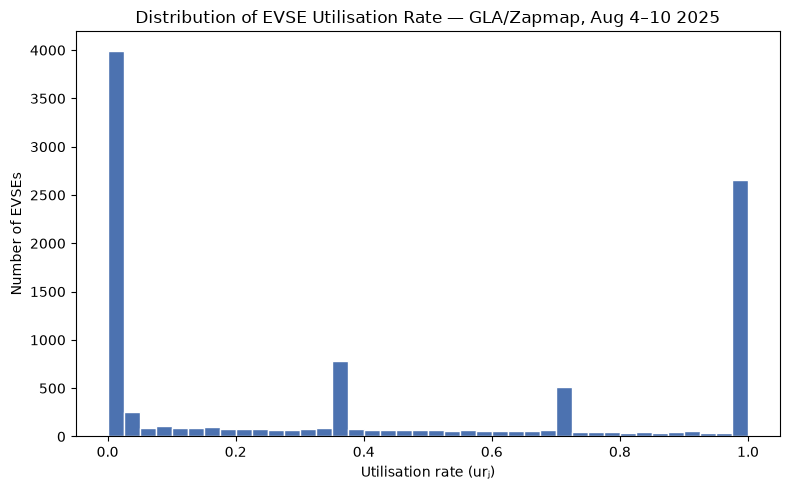

Saved: fig_ur_distribution.png


In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evse_duration["ur_j"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utilisation rate (urⱼ)")
ax.set_ylabel("Number of EVSEs")
ax.set_title("Distribution of EVSE Utilisation Rate — GLA/Zapmap, Aug 4–10 2025")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_ur_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_ur_distribution.png")

### Fig B2 — Sᵢᵉᶠᶠ choropleth

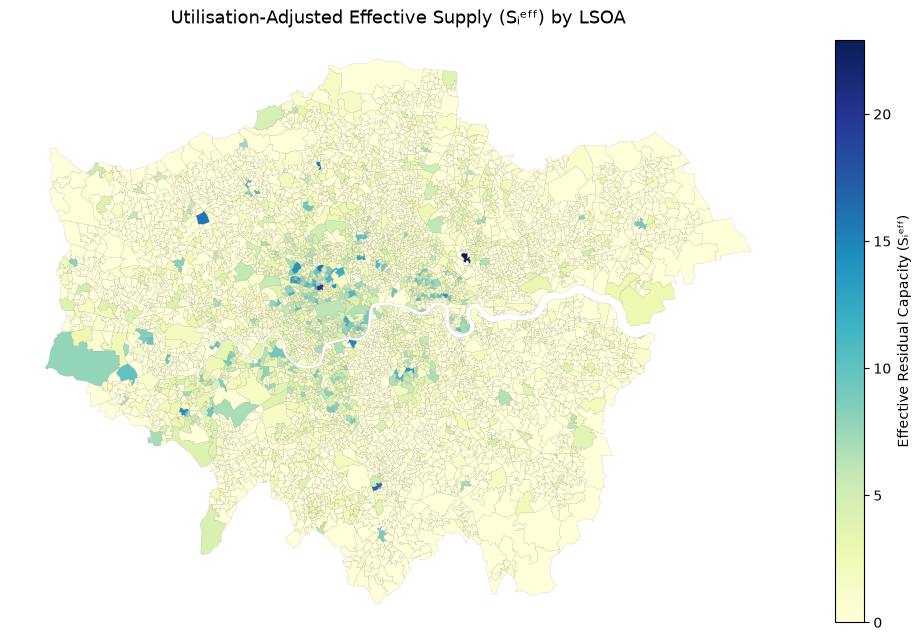

Saved: fig_seff_map.png


In [36]:
seff_map = lsoa_london[["lsoa_code", "geometry"]].merge(seff_london, on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
seff_map.plot(
    column="seff", cmap="YlGnBu", linewidth=0.1,
    edgecolor="grey", legend=True, ax=ax,
    legend_kwds={"label": "Effective Residual Capacity (Sᵢᵉᶠᶠ)", "shrink": 0.6}
)
ax.set_title("Utilisation-Adjusted Effective Supply (Sᵢᵉᶠᶠ) by LSOA", fontsize=13)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_seff_map.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_seff_map.png")

### Fig B3 — session duration distribution

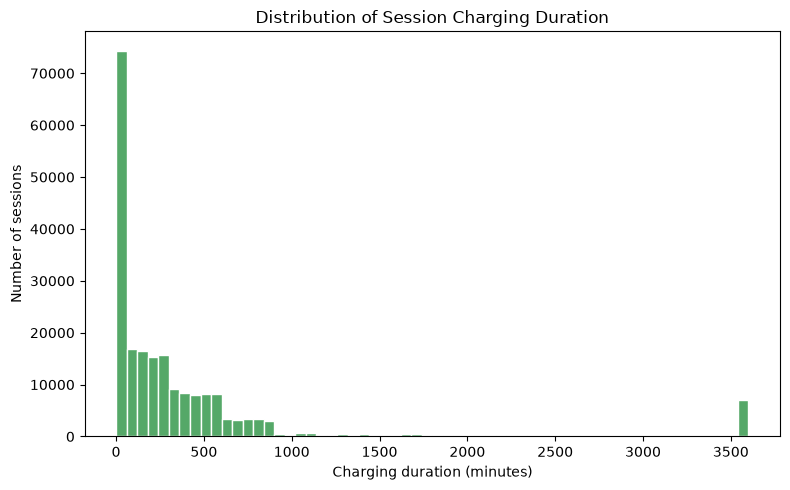

Saved: fig_duration_distribution.png


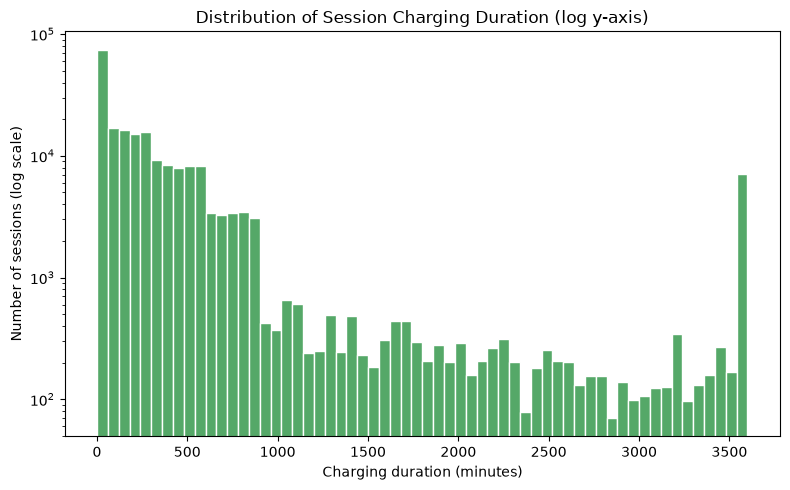

Saved: fig_duration_distribution_log.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(zapmap_clean["charging_duration"], bins=60, color="#55A868", edgecolor="white")
ax.set_xlabel("Charging duration (minutes)")
ax.set_ylabel("Number of sessions")
ax.set_title("Distribution of Session Charging Duration")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_duration_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_duration_distribution.png")

# Log y-axis version — makes bimodality (short top-up vs long overnight sessions) easier to see
# when the bulk of sessions are short and a long tail dominates a linear-scale plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(zapmap_clean["charging_duration"], bins=60, color="#55A868", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Charging duration (minutes)")
ax.set_ylabel("Number of sessions (log scale)")
ax.set_title("Distribution of Session Charging Duration (log y-axis)")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_duration_distribution_log.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_duration_distribution_log.png")

### Fig B4 — location-level utilisation variance

Locations with >1 EVSE: 1527
count    1527.000000
mean        0.176603
std         0.174801
min         0.000000
25%         0.012767
50%         0.121550
75%         0.308310
max         0.700653
Name: std, dtype: float64


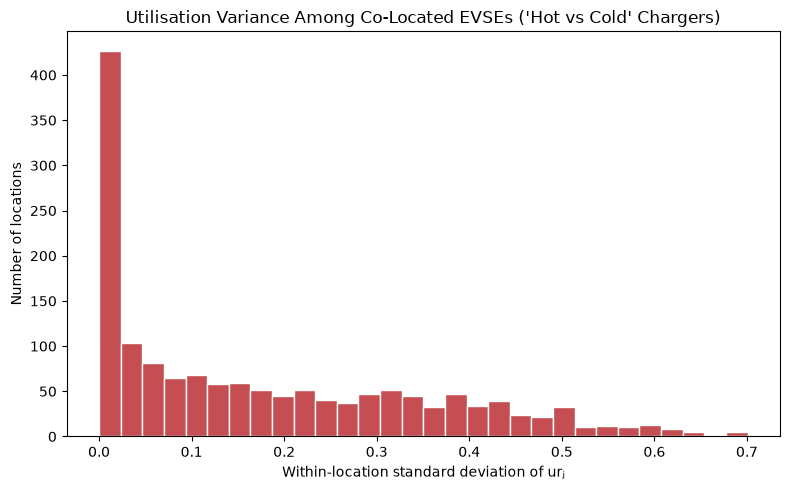

Saved: fig_location_level_variance.png


In [38]:
# Step 6: do co-located EVSEs (same location_id) show different utilisation levels?
evse_per_location = evse_joined.groupby("location_id")["ur_j"].agg(["count", "std", "mean"]).reset_index()
multi_evse_locations = evse_per_location[evse_per_location["count"] > 1].dropna(subset=["std"])

print(f"Locations with >1 EVSE: {len(multi_evse_locations)}")
print(multi_evse_locations["std"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(multi_evse_locations["std"], bins=30, color="#C44E52", edgecolor="white")
ax.set_xlabel("Within-location standard deviation of urⱼ")
ax.set_ylabel("Number of locations")
ax.set_title("Utilisation Variance Among Co-Located EVSEs ('Hot vs Cold' Chargers)")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_location_level_variance.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_location_level_variance.png")

### update pipeline_summary.csv

In [39]:
# Fill in the "EVSEs matched to LSOA via spatial join" row that was left pending in 02_data_cleaning
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
pipeline_summary.loc[
    pipeline_summary["Item"] == "EVSEs matched to LSOA via spatial join", "Count"
] = str(matched)

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                          Item                                   Count
                 LSOAs loaded (Greater London)                                    4994
   On-street EVSE locations (OpenStreetEV_GLA)                                   21366
 Session records (join_august2025, post-clean)                                  215037
                  Unique EVSEs with ≥1 session                                   10465
        EVSEs matched to LSOA via spatial join                                   10465
Candidate sites generated (Camden, pre-buffer) Pending — Notebook 4 (Camden toy model)
    Candidate sites after 50m exclusion buffer Pending — Notebook 4 (Camden toy model)


## Block C — Temporal Patterns (Hour of Day, Day of Week)

This block examines when public charging sessions occur across the week, directly addressing the temporal demand patterns requested in supervisor feedback. Note that the observation window covers a single 7-day period (Aug 4–10, 2025), so each day-of-week category reflects one observed occurrence rather than a multi-week average — declared as Limitation L6 in the proposal. The block also explores inter-session intervals at the same EVSE as a secondary signal of queuing/turnover frequency.

### Fig C1 — sessions by hour

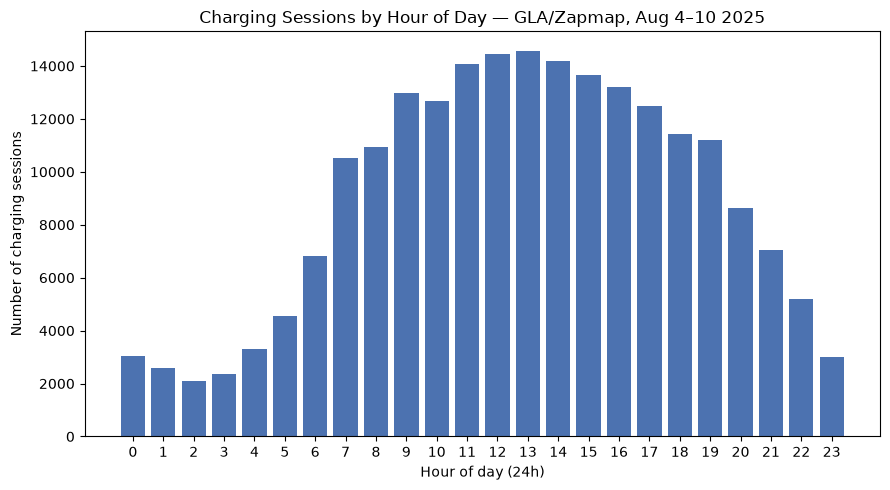

Saved: fig_sessions_by_hour.png


In [40]:
sessions_by_hour = zapmap_clean.groupby("hour").size().reset_index(name="session_count")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(sessions_by_hour["hour"], sessions_by_hour["session_count"], color="#4C72B0")
ax.set_xlabel("Hour of day (24h)")
ax.set_ylabel("Number of charging sessions")
ax.set_title("Charging Sessions by Hour of Day — GLA/Zapmap, Aug 4–10 2025")
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_sessions_by_hour.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_sessions_by_hour.png")

### Fig C2 — sessions by day of week

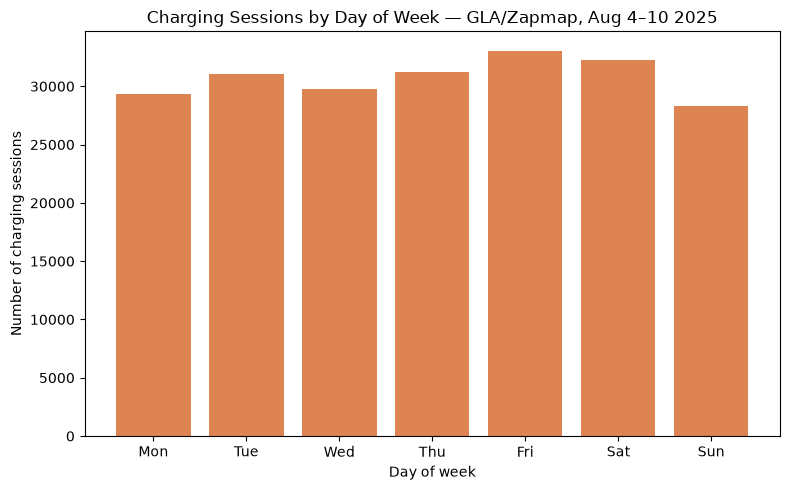

Saved: fig_sessions_by_dow.png

day  session_count
Mon          29331
Tue          31048
Wed          29799
Thu          31241
Fri          33061
Sat          32270
Sun          28287


In [41]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sessions_by_dow = zapmap_clean.groupby("dayofweek").size().reset_index(name="session_count")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sessions_by_dow["dayofweek"], sessions_by_dow["session_count"], color="#DD8452")
ax.set_xlabel("Day of week")
ax.set_ylabel("Number of charging sessions")
ax.set_title("Charging Sessions by Day of Week — GLA/Zapmap, Aug 4–10 2025")
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_sessions_by_dow.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_sessions_by_dow.png")
print()
print(sessions_by_dow.assign(day=dow_labels)[["day", "session_count"]].to_string(index=False))

### Fig C3 — inter-session intervals

Inter-session interval (hours) stats:
count    204572.000000
mean          3.576549
std          11.545207
min           0.000000
25%           0.000000
50%           0.000000
75%           0.201389
max         166.242500
Name: interval_hours, dtype: float64


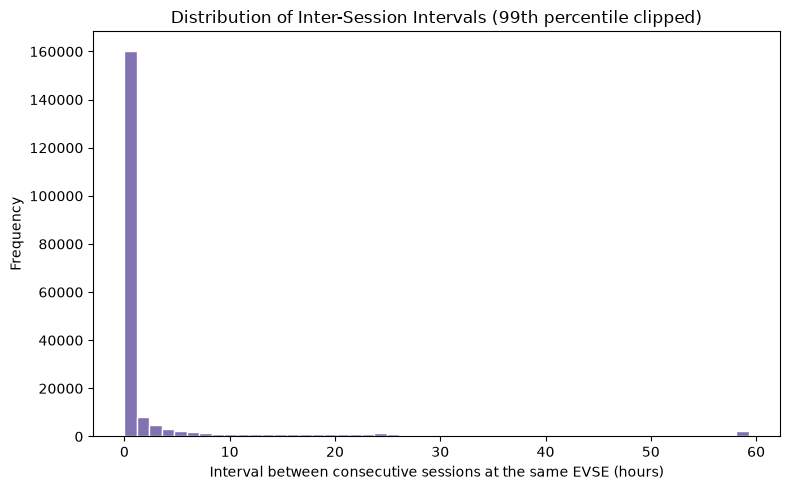

Saved: fig_session_intervals.png


In [42]:
# Inter-session interval at the same EVSE: gap between consecutive session start times.
# Short intervals suggest high turnover/queuing; long intervals suggest genuine under-utilisation.
zapmap_sorted = zapmap_clean.sort_values(["evse_id", "charging_start"])
zapmap_sorted["prev_start"] = zapmap_sorted.groupby("evse_id")["charging_start"].shift(1)
zapmap_sorted["interval_hours"] = (
    zapmap_sorted["charging_start"] - zapmap_sorted["prev_start"]
).dt.total_seconds() / 3600

intervals = zapmap_sorted["interval_hours"].dropna()
intervals = intervals[intervals >= 0]  # safety: drop any negative gaps from data artefacts

print("Inter-session interval (hours) stats:")
print(intervals.describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(intervals.clip(upper=intervals.quantile(0.99)), bins=50, color="#8172B2", edgecolor="white")
ax.set_xlabel("Interval between consecutive sessions at the same EVSE (hours)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Inter-Session Intervals (99th percentile clipped)")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_session_intervals.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_session_intervals.png")

## Block D — Correlation Analysis: Income Deprivation vs Supply Metrics

This block tests the spatial relationship between income deprivation and EV charging supply at LSOA level using three population-normalised metrics, directly responding to supervisor feedback that a correlation table — even with weak correlations — is informative. It also examines whether income deprivation is associated with charger power tier (slow vs rapid), a quality dimension distinct from raw supply quantity.

### build LSOA-level table

In [43]:
# Merge income score, Sᵢᵉᶠᶠ, driving-age population, and EVSE count at LSOA level
# evse_count and mean_ur come from the spatial join already done in Block B (evse_joined)
evse_counts = evse_joined.dropna(subset=["lsoa_code"]).groupby("lsoa_code").agg(
    evse_count=("evse_id", "nunique"),
    mean_ur=("ur_j", "mean"),
).reset_index()

corr_table = (
    census_london[["lsoa_code", "lsoa_name", "driving_age_pop"]]
    .merge(imd_london[["lsoa_code", "income_score", "income_decile"]], on="lsoa_code", how="left")
    .merge(seff_london[["lsoa_code", "seff"]], on="lsoa_code", how="left")
    .merge(evse_counts, on="lsoa_code", how="left")
)

# LSOAs with no observed EVSE get 0 count / 0 effective supply; mean_ur left as NaN (no sessions to average)
corr_table["evse_count"] = corr_table["evse_count"].fillna(0)
corr_table["seff"] = corr_table["seff"].fillna(0)

# Normalise supply metrics by driving-age population, per 1,000 residents
corr_table["evse_per_1000"] = (corr_table["evse_count"] / corr_table["driving_age_pop"]) * 1000
corr_table["seff_per_1000"] = (corr_table["seff"] / corr_table["driving_age_pop"]) * 1000

print("=== LSOA-level Correlation Table ===")
print("Shape:", corr_table.shape)
print(corr_table.head(3).to_string())

=== LSOA-level Correlation Table ===
Shape: (4994, 10)
   lsoa_code            lsoa_name  driving_age_pop  income_score  income_decile      seff  evse_count   mean_ur  evse_per_1000  seff_per_1000
0  E01000001  City of London 001A             1346         0.013             10  2.171131         3.0  0.276290       2.228826       1.613024
1  E01000002  City of London 001B             1293         0.018             10  9.489187        21.0  0.548134      16.241299       7.338891
2  E01000003  City of London 001C             1500         0.107              8  5.629365         9.0  0.374515       6.000000       3.752910


### Pearson r table

In [44]:
from scipy.stats import pearsonr

pairs = [
    ("income_score", "evse_per_1000", "Income score vs EVSE per 1,000 residents"),
    ("income_score", "seff_per_1000", "Income score vs residual capacity (Sᵢᵉᶠᶠ) per 1,000 residents"),
    ("income_score", "mean_ur",       "Income score vs mean utilisation rate (urⱼ)"),
]

results = []
for x, y, label in pairs:
    sub = corr_table[[x, y]].dropna()
    r, p = pearsonr(sub[x], sub[y])
    results.append((label, round(r, 4), round(p, 4), len(sub)))

corr_results = pd.DataFrame(results, columns=["Relationship", "Pearson r", "p-value", "n"])
print(corr_results.to_string(index=False))

output_path = os.path.join(BASE, "05_processed/correlation_results.csv")
corr_results.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

                                                 Relationship  Pearson r  p-value    n
                     Income score vs EVSE per 1,000 residents    -0.0938   0.0000 4994
Income score vs residual capacity (Sᵢᵉᶠᶠ) per 1,000 residents    -0.0777   0.0000 4994
                  Income score vs mean utilisation rate (urⱼ)    -0.0237   0.2325 2548

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/correlation_results.csv


### Fig D1 — income vs Sᵢᵉᶠᶠ scatter

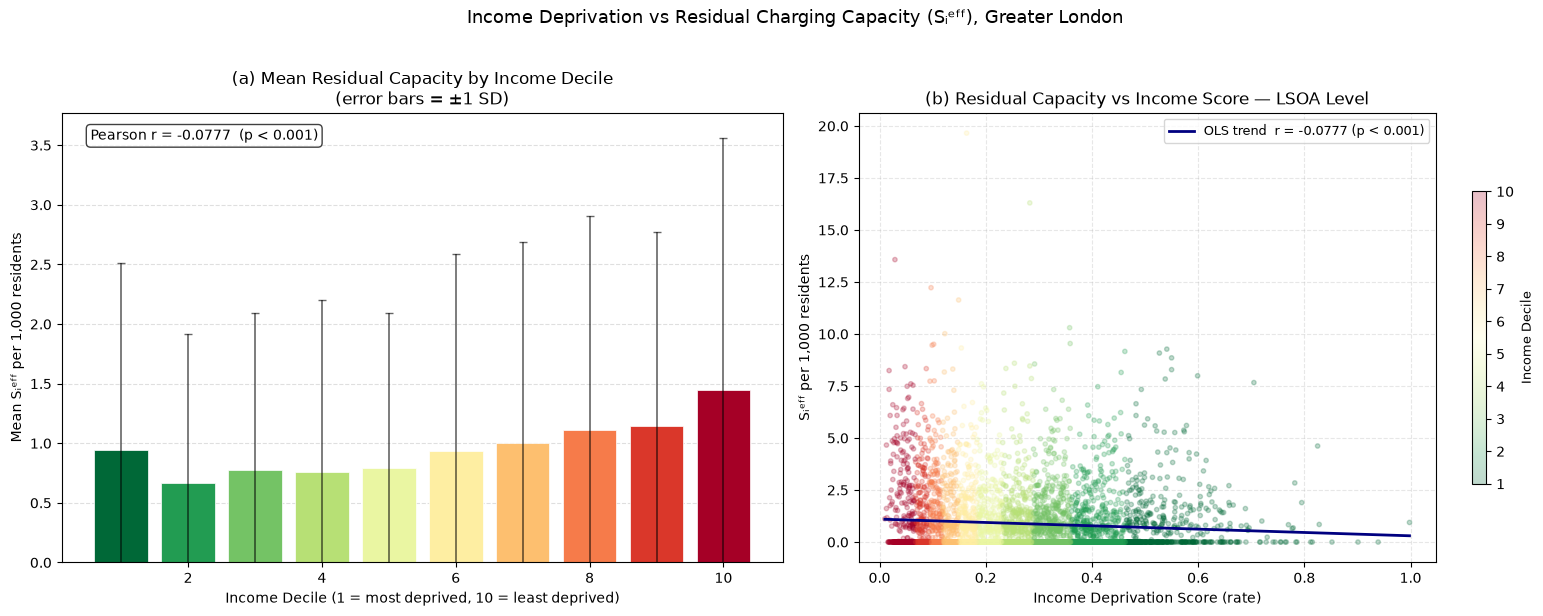

Saved: fig_income_vs_seff_scatter.png (upgraded bar+scatter version)


In [45]:
# Fig D1 (upgraded) — bar chart by income decile (left) + scatter with OLS trend on continuous score (right)
decile_stats_seff = corr_table.dropna(subset=["income_decile", "seff_per_1000"]).groupby("income_decile")["seff_per_1000"].agg(
    mean_seff="mean", std_seff="std", n="count"
).reset_index()
decile_stats_seff["income_decile"] = decile_stats_seff["income_decile"].astype(int)

# Pull the already-computed Pearson r (income_score vs seff_per_1000) from corr_results — keeps this
# figure consistent with the official correlation table rather than recomputing a separate decile-based r
r_seff = corr_results.loc[corr_results["Relationship"].str.contains("residual capacity"), "Pearson r"].values[0]
p_seff = corr_results.loc[corr_results["Relationship"].str.contains("residual capacity"), "p-value"].values[0]
p_label = "p < 0.001" if p_seff < 0.001 else f"p = {p_seff:.3f}"

bar_colours = [plt.get_cmap("RdYlGn_r", 10)(i / 9) for i in range(10)]  # decile 1 (most deprived) = red

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart with SD error bars
ax1.bar(
    decile_stats_seff["income_decile"], decile_stats_seff["mean_seff"],
    yerr=decile_stats_seff["std_seff"], color=bar_colours, edgecolor="white", linewidth=0.5,
    error_kw={"elinewidth": 1.2, "capsize": 3, "alpha": 0.6}, zorder=2
)
ax1.set_xlabel("Income Decile (1 = most deprived, 10 = least deprived)")
ax1.set_ylabel("Mean Sᵢᵉᶠᶠ per 1,000 residents")
ax1.set_ylim(bottom=0)
ax1.set_title("(a) Mean Residual Capacity by Income Decile\n(error bars = ±1 SD)")
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax1.text(0.04, 0.94, f"Pearson r = {r_seff:.4f}  ({p_label})", transform=ax1.transAxes, fontsize=10,
          bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))

# Right: scatter on continuous income_score with OLS trend line
sc = ax2.scatter(
    corr_table["income_score"], corr_table["seff_per_1000"],
    c=corr_table["income_decile"], cmap="RdYlGn_r", vmin=1, vmax=10, alpha=0.25, s=10, zorder=2
)
valid_mask = corr_table["income_score"].notna() & corr_table["seff_per_1000"].notna()
z = np.polyfit(corr_table.loc[valid_mask, "income_score"], corr_table.loc[valid_mask, "seff_per_1000"], 1)
x_line = np.linspace(corr_table["income_score"].min(), corr_table["income_score"].max(), 100)
ax2.plot(x_line, np.polyval(z, x_line), color="navy", linewidth=2, zorder=3,
          label=f"OLS trend  r = {r_seff:.4f} ({p_label})")
ax2.set_xlabel("Income Deprivation Score (rate)")
ax2.set_ylabel("Sᵢᵉᶠᶠ per 1,000 residents")
ax2.set_title("(b) Residual Capacity vs Income Score — LSOA Level")
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(linestyle="--", alpha=0.3, zorder=1)
cbar = plt.colorbar(sc, ax=ax2, shrink=0.65)
cbar.set_label("Income Decile", fontsize=9)

fig.suptitle("Income Deprivation vs Residual Charging Capacity (Sᵢᵉᶠᶠ), Greater London", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_income_vs_seff_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_income_vs_seff_scatter.png (upgraded bar+scatter version)")

### Fig D2 — income vs EVSE density

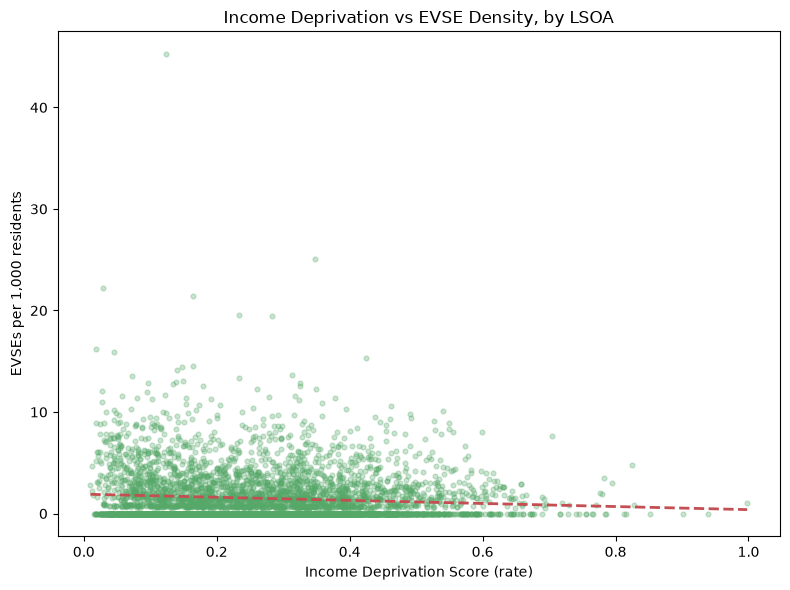

Saved: fig_income_vs_evse_density.png


In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(corr_table["income_score"], corr_table["evse_per_1000"], alpha=0.3, s=12, color="#55A868")

z = np.polyfit(corr_table["income_score"], corr_table["evse_per_1000"], 1)
x_line = np.linspace(corr_table["income_score"].min(), corr_table["income_score"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="#C44E52", linewidth=2, linestyle="--")

ax.set_xlabel("Income Deprivation Score (rate)")
ax.set_ylabel("EVSEs per 1,000 residents")
ax.set_title("Income Deprivation vs EVSE Density, by LSOA")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_income_vs_evse_density.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_income_vs_evse_density.png")

### power band vs income decile

In [47]:
# Cross-tabulate charger power band against LSOA income decile (unique EVSE-level power_band)
evse_power = zapmap_clean.groupby("evse_id")["power_band"].first().reset_index()

power_lsoa = evse_joined[["evse_id", "lsoa_code"]].merge(evse_power, on="evse_id", how="left")
power_lsoa = power_lsoa.merge(imd_london[["lsoa_code", "income_decile"]], on="lsoa_code", how="left")

power_cross = pd.crosstab(power_lsoa["income_decile"], power_lsoa["power_band"], normalize="index") * 100

print("=== Power Band Share (%) by Income Decile ===")
print(power_cross.round(1).to_string())

=== Power Band Share (%) by Income Decile ===
power_band     1. Slow  2. Fast (AC)  2. Fast (DC)  3. Rapid  4. Ultra-rapid
income_decile                                                               
1                 77.0          13.5           0.0       3.3             6.2
2                 75.2          15.8           0.0       2.7             6.3
3                 73.8          14.1           0.0       4.9             7.2
4                 70.4          15.3           0.0       4.3             9.9
5                 78.8          13.0           0.0       3.5             4.7
6                 77.1          13.5           0.1       4.4             4.9
7                 79.5          11.8           0.1       6.6             2.0
8                 85.6          11.6           0.0       0.6             2.2
9                 84.4           9.7           0.0       4.2             1.7
10                78.0          19.2           0.0       1.1             1.7


### Fig D3 — power tier composition

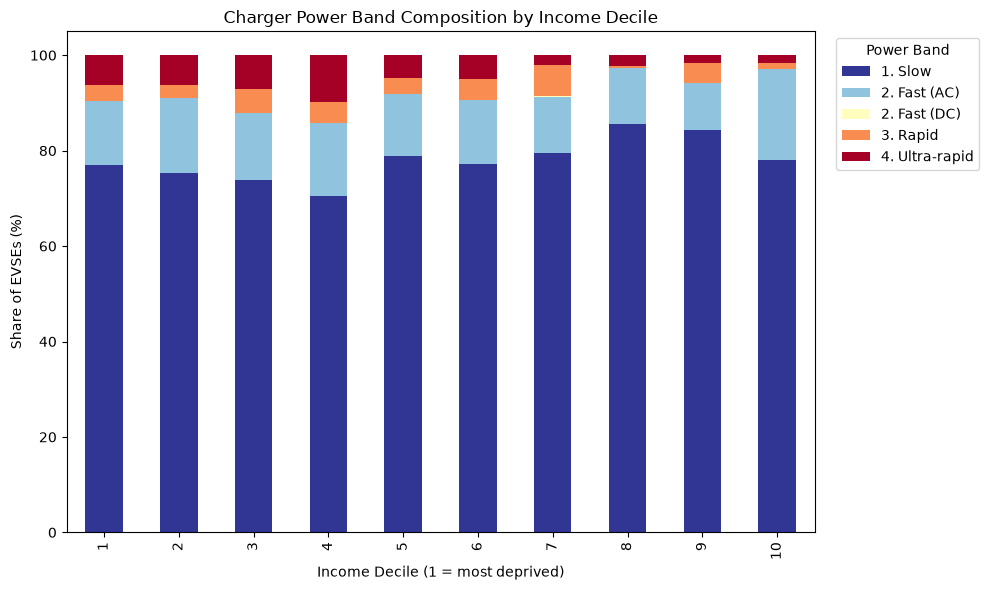

Saved: fig_power_tier_vs_income.png


In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
power_cross.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlBu_r")
ax.set_xlabel("Income Decile (1 = most deprived)")
ax.set_ylabel("Share of EVSEs (%)")
ax.set_title("Charger Power Band Composition by Income Decile")
ax.legend(title="Power Band", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_power_tier_vs_income.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_power_tier_vs_income.png")